# Latent Network Viewer

This notebook loads a trained latent network from `data/latent_network/latent_network.pt`, then plots:

1. prediction vs. target neural activity for one dataset/session/condition
2. latent unit activity and recurrent weights `W`

The final cells expose `W` and the unit slices so you can experiment with recurrent weights interactively.

In [349]:
%matplotlib inline

import copy
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import sklearn

import _8_LatentNetwork as ln
importlib.reload(ln)

checkpoint_path = Path(ln.SAVE_LATENT_PATH) / 'latent_network.pt'
print('checkpoint:', checkpoint_path)
print('exists:', checkpoint_path.exists())

checkpoint: data/latent_network/latent_network.pt
exists: True


## Load The Trained Model

`results` contains the trained RNN, trained session readouts, training metadata, and loss history.

In [350]:
results = ln.load_latent_network(checkpoint_path=str(checkpoint_path))

rnn = results['rnn']
datasets = results['datasets']
loss_history = results['loss_history']

print('loaded datasets:', len(datasets))
print('RNN units:', rnn.n_units)
print('time bins:', rnn.n_time)
print('loss history length:', len(results['loss_history']))

loaded datasets: 5
RNN units: 120
time bins: 24
loss history length: 4000


In [348]:
loss_history_rank5 = np.copy(loss_history)

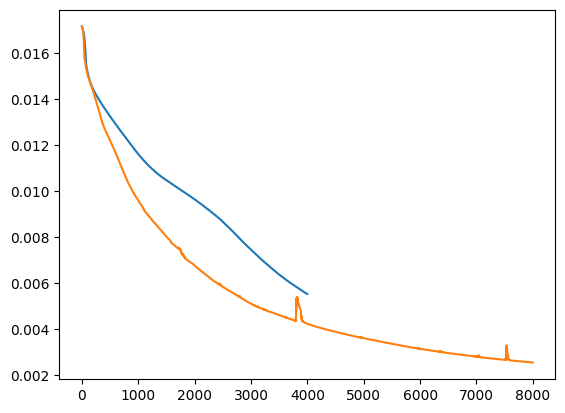

In [351]:
plt.figure()
plt.plot(loss_history)
plt.plot(loss_history_rank5)


## Choose An Example

Change these values to inspect a different target dataset, session, or condition.

In [142]:
dataset_idx = 0   # which cells/activity file to use
fx = 0            # session index, 0..32
condition = 'P1'  # one of ln.CONDITIONS, currently ['P1', 'A1']

print('conditions:', ln.CONDITIONS)

conditions: ['P1', 'A1']


## Plot Prediction Vs. Target

This calls the same plotting helper used by `_8_LatentNetwork.py`. Rows are top neurons and columns are time bins.

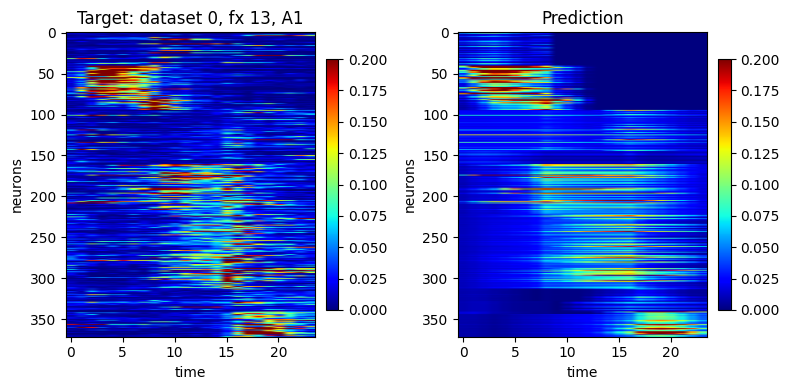

In [352]:
ln.plot_prediction_vs_target(
    results,
    dataset_idx=dataset_idx,
    fx=13,
    condition='A1',
)
plt.show()

## Plot Latent Unit Activity And Recurrent Weights

The units are ordered as `S`, `D`, `R`, and within each population as `Group0`, `Group1`, `Group2`, `Group3`.

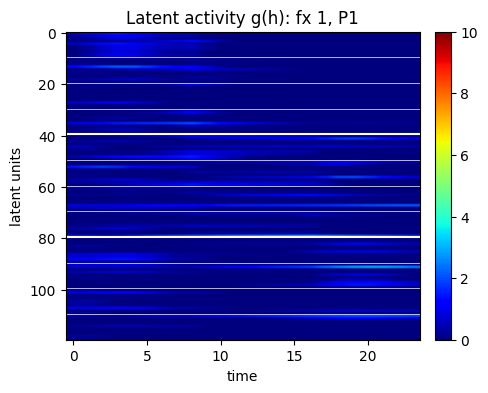

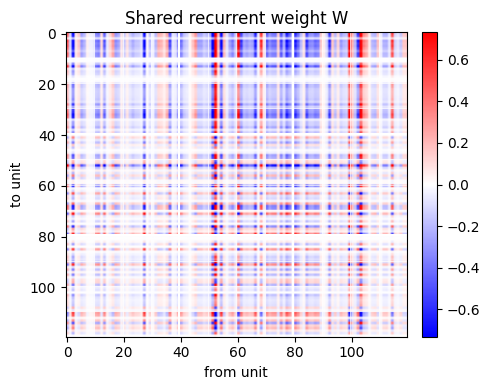

In [353]:
ln.plot_latent_activity_and_weights(
    results,
    condition=condition,
    fx = 1
)
plt.show()

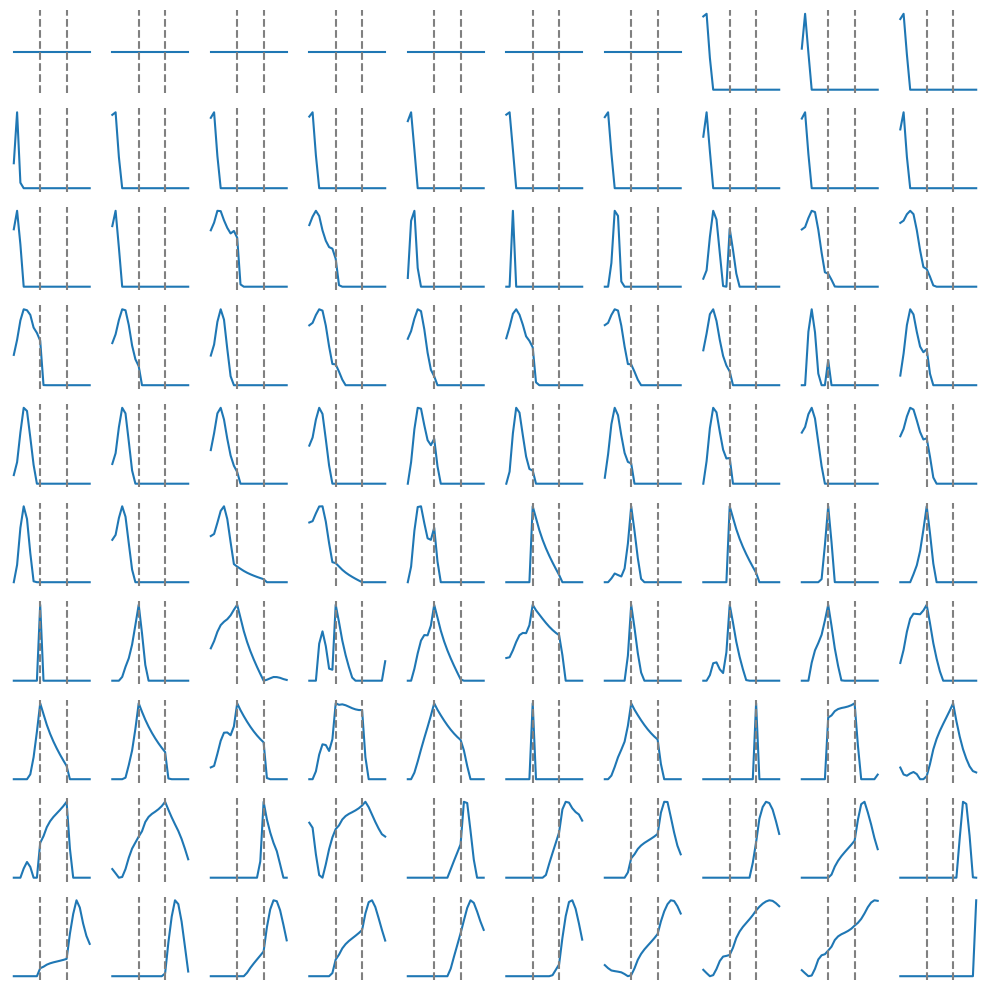

In [354]:
fx=21
condition='P1'
rnn.eval()
g_by_condition = rnn(fx)
latent_activity = g_by_condition[condition].detach().numpy().T
cells_sorted = np.argsort(np.argmax(latent_activity,axis=1))

plt.figure(figsize=(10,10))
for ix, ic in enumerate(np.arange(20,120)):
    plt.subplot(10,10,ix+1)
    plt.plot(latent_activity[cells_sorted[ic]])
    plt.axvline(8,color='gray',linestyle='--')
    plt.axvline(16,color='gray',linestyle='--')
    plt.axis('off')
plt.tight_layout()


## Inspect The Recurrent Weight Matrix

`W[to_unit, from_unit]` is used in the RNN update through `g(h) @ W.T`. The recurrent matrix is shared across sessions, so `rnn.recurrent_weight(fx)` returns the same W for every fx.

In [301]:
for fx in range(33):
    W = rnn.recurrent_weight(fx).detach().cpu().numpy()

    plt.figure(figsize=(6,6))
    wlim = np.max(np.abs(W)) / 4
    if wlim == 0:
        wlim = 1
    plt.imshow(W, cmap='bwr', vmin=-wlim, vmax=wlim, aspect='auto')
    plt.title('Recurrent weight W')
    plt.xlabel('from unit')
    plt.ylabel('to unit')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f'figure/latent_network/wrec/w{fx}')
    plt.close()

W shape: (120, 120)
W min / mean / max: -1.9608183 -0.02280326 3.9002175

Unit slices:
('S', 'Group0'): 0:10
('S', 'Group1'): 10:20
('S', 'Group2'): 20:30
('S', 'Group3'): 30:40
('D', 'Group0'): 40:50
('D', 'Group1'): 50:60
('D', 'Group2'): 60:70
('D', 'Group3'): 70:80
('R', 'Group0'): 80:90
('R', 'Group1'): 90:100
('R', 'Group2'): 100:110
('R', 'Group3'): 110:120
wstart: 40
wstop: 80


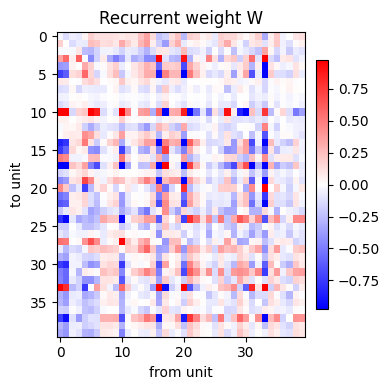

In [302]:
W = rnn.recurrent_weight(fx).detach().cpu().numpy()

print('W shape:', W.shape)
print('W min / mean / max:', W.min(), W.mean(), W.max())
print('\nUnit slices:')
for key, sl in ln.UNIT_SLICES.items():
    print(f'{key}: {sl.start}:{sl.stop}')
    if key == ('D','Group0'):
        wstart = sl.start
    if key == ('D','Group3'):
        wstop = sl.stop
print(f'wstart: {wstart}')
print(f'wstop: {wstop}')

Wtrim = W[wstart:wstop,wstart:wstop]
plt.figure(figsize=(4,4))
wlim = np.max(np.abs(W)) / 4
if wlim == 0:
    wlim = 1
plt.imshow(Wtrim, cmap='bwr', vmin=-wlim, vmax=wlim, aspect='auto')
plt.title('Recurrent weight W')
plt.xlabel('from unit')
plt.ylabel('to unit')
plt.colorbar(fraction=0.046, pad=0.04)
# plt.xlim([40,80])
# plt.ylim([40,80])
plt.tight_layout()

In [343]:
N=10
fx=10
sv_cumsum = np.zeros((33,12*N))
expvar_cumsum = np.zeros((33,12*N))
components = np.zeros((33,12*N,12*N))
for fx in range(33):
    W = rnn.recurrent_weight(fx).detach().cpu().numpy()
    # U, S, Vh = np.linalg.svd(W)
    # sv_cumsum[fx] = np.cumsum(S**2) / np.sum(S**2)
    pca = sklearn.decomposition.PCA()
    pca.fit(W.T)
    expvar_cumsum[fx] = np.cumsum(pca.explained_variance_ratio_)
    components[fx] = pca.components_

In [344]:
effdim = np.argmax(expvar_cumsum > 0.8,axis=1)+1
effdim

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Text(0, 0.5, 'explained variance')

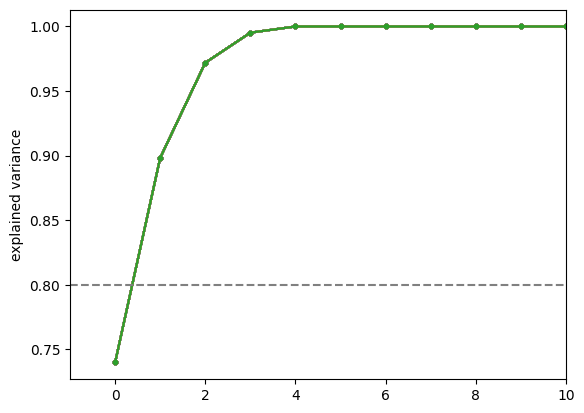

In [345]:
plt.figure()
for fx in range(33):
    # plt.plot(sv_cumsum[fx])
    plt.plot(expvar_cumsum[fx],marker='.')
plt.xlim([-1,10])
plt.axhline(0.8,color='gray',linestyle='--')
# plt.ylim([0.7,0.9])
plt.ylabel('explained variance')

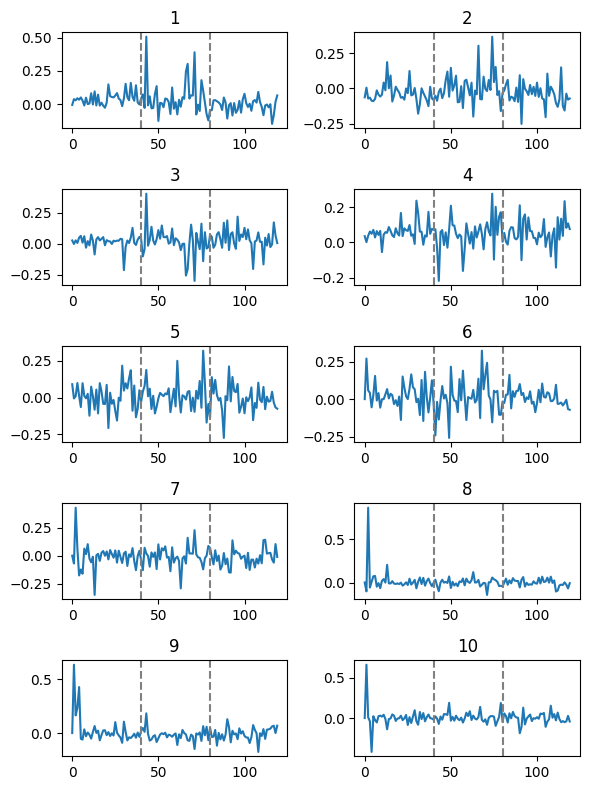

In [346]:
fx1 = 3
fx2 = 23
plt.figure(figsize=(6,8))
for ic in range(10):
    plt.subplot(5,2,ic+1)
    # plt.plot(components[fx1,ic])
    plt.plot(components[fx2,ic])
    plt.axvline(40,color='gray',linestyle='--')
    plt.axvline(80,color='gray',linestyle='--')
    plt.title(f'{ic+1}')
plt.tight_layout()

# SVD of the recurrent weights

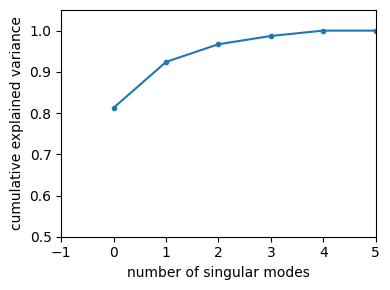

In [333]:
results = ln.load_latent_network()
rnn = results['rnn']

fx = 2  # choose session
W = rnn.recurrent_weight(fx).detach().cpu().numpy()

U, S, Vh = np.linalg.svd(W, full_matrices=False)

cumulative_explained_variance = np.cumsum(S**2) / np.sum(S**2)

plt.figure(figsize=(4, 3))
plt.plot(cumulative_explained_variance, '.-')
plt.xlabel('number of singular modes')
plt.ylabel('cumulative explained variance')
plt.ylim([0.5, 1.05])
plt.xlim([-1,5])
plt.tight_layout()